# TODO

- checker avec Dorian et Julien la meilleure periode pour definir la pluie des recoltes
- choisir la date de debut des vendanges, selon TL plus probablement que selon Latour

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.linear_model import LinearRegression
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 4)

pheno = pd.read_excel('data/generated_pheno.xlsx', index_col=0)

pheno['Half-harvest'] = (pheno['Begin harvest'] + (pheno['End harvest'] - pheno['Begin harvest'])/2).dt.normalize()

display(pheno.head())

,Budburst,Begin flowering,End flowering,Begin véraison,Half véraison,Begin harvest,End harvest,Budburst - flowering interval,Flowering - véraison interval,Véraison - harvest interval,Growing season duration,Half-harvest
Année,,,,,,,,,,,,
1960,1960-03-18,1960-05-24,1960-05-30,1960-07-20,1960-08-02,1960-09-15,1960-10-06,67,64,44,181,1960-09-25
1961,1961-03-10,1961-05-16,1961-05-30,1961-07-23,1961-08-05,1961-09-17,1961-10-14,67,67,43,191,1961-09-30
1962,1962-04-14,1962-06-08,1962-06-17,1962-08-03,1962-08-16,1962-10-01,1962-10-22,55,60,46,170,1962-10-11
1963,1963-04-08,1963-06-13,1963-06-20,1963-08-13,1963-08-15,1963-10-01,1963-10-28,66,56,47,176,1963-10-14
1964,1964-04-06,1964-06-01,1964-06-14,1964-07-31,1964-08-13,1964-09-21,1964-10-20,56,60,39,168,1964-10-05


In [67]:
weather_st_em = pd.read_csv('data/weather/generated_weather_st_em.csv', parse_dates=['Date']).set_index('Date')
prices_st_em = pd.read_excel('data/prices/generated_average_prices_st_em.xlsx', index_col=0)

weather_medoc = pd.read_csv('data/weather/generated_weather_pauillac.csv', parse_dates=['Date']).set_index('Date')
prices_medoc = pd.read_excel('data/prices/generated_average_prices_medoc.xlsx', index_col=0)

weather_st_em = weather_st_em.drop(['Pl','Ps','Peff', 'SoilHum', 'Evap'], axis = 1)
weather_st_em['Frost'] = (weather_st_em['Tn'] < 0).astype(int) * (-weather_st_em['Tn'])
weather_st_em['DTR'] = weather_st_em['Tx'] - weather_st_em['Tn']

weather_medoc = weather_medoc.drop(['Pl','Ps','Peff', 'SoilHum', 'Evap'], axis = 1)
weather_medoc['Frost'] = (weather_medoc['Tn'] < 0).astype(int) * (-weather_medoc['Tn'])
weather_medoc['DTR'] = weather_medoc['Tx'] - weather_medoc['Tn']

#weather['CI'] = (weather['Tn'] < 15).astype(int)
#weather['Huglin'] = ((weather['Tx']-10) + (weather['Tm']-10))/2

#weather['Heavy Rain'] = (weather['P'] > 40).astype(int)
weather_st_em['Stress'] = 0.5*weather_st_em['ETP'] - weather_st_em['P']
weather_medoc['Stress'] = 0.5*weather_medoc['ETP'] - weather_medoc['P']

#weather['Very high'] = (weather['Tx'] > 36).astype(int) * (weather['Tx'] - 36)
weather_st_em = weather_st_em[['Tn', 'Tm', 'Tx', 'DTR', 'Wind', 'Sun', 'ETP', 'Stress', 'P', 'Frost']]
weather_medoc = weather_medoc[['Tn', 'Tm', 'Tx', 'DTR', 'Wind', 'Sun', 'ETP', 'Stress', 'P', 'Frost']]


ORIG_WEATHER_FEATURES = list(weather_medoc.columns)

#weather['Tm-25'] = (weather['Tx']<30).astype(int) * (weather['Tm']>20).astype(int)
weather_st_em['GDD10'] = ((weather_st_em['Tx']+weather_st_em['Tx'])/2 > 10).astype(int) * ((weather_st_em['Tx']+weather_st_em['Tx'])/2 - 10)
weather_medoc['GDD10'] = ((weather_medoc['Tx']+weather_medoc['Tx'])/2 > 10).astype(int) * ((weather_medoc['Tx']+weather_medoc['Tx'])/2 - 10)

display(weather_medoc.head())

,Tn,Tm,Tx,DTR,Wind,Sun,ETP,Stress,P,Frost,GDD10
Date,,,,,,,,,,,
1960-01-01,9.7,11.9,13.5,3.8,5.8,394.8,1.1,-8.55,9.1,-0.0,3.5
1960-01-02,11.2,12.4,14.0,2.8,8.4,333.7,1.4,-6.80,7.5,-0.0,4.0
1960-01-03,11.1,12.3,13.0,1.9,4.7,254.8,0.8,-1.60,2.0,-0.0,3.0
1960-01-04,12.4,12.9,13.9,1.5,1.5,363.0,0.7,0.35,0.0,-0.0,3.9
1960-01-05,9.9,10.6,11.7,1.8,2.4,331.9,0.4,0.20,0.0,-0.0,1.7


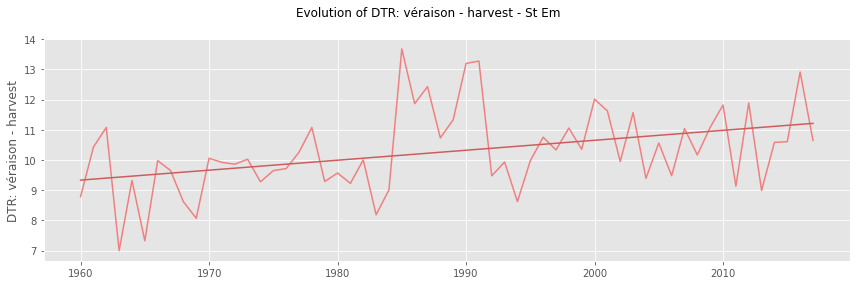

,Tn: budburst - flowering,Tn: flowering,Tn: flowering - véraison,Tn: véraison - harvest,Tn: harvest,Tm: budburst - flowering,Tm: flowering,Tm: flowering - véraison,Tm: véraison - harvest,Tm: harvest,...,P: flowering,P: flowering - véraison,P: véraison - harvest,P: harvest,Frost: budburst - flowering,Growing Season Tm,Winter Rain,Floraison date,GDD10,Stress
1960,9.054412,14.485714,15.455385,14.993333,13.190909,12.882353,18.628571,19.030769,18.444444,15.513636,...,1.1,118.8,140.9,209.9,0.0,16.948634,0.000000,145,1989.8,-77.35
1961,8.794118,10.453333,15.214706,15.502273,14.767857,12.645588,14.573333,18.823529,19.543182,18.392857,...,35.7,90.0,14.3,92.6,0.0,17.506011,5.003289,136,2249.1,94.40
1962,9.800000,14.020000,15.606557,14.308511,11.209091,13.421429,18.350000,19.372131,18.642553,14.913636,...,8.8,37.2,50.4,44.3,0.0,16.615847,3.417763,159,2111.4,106.75
1963,10.750746,14.475000,15.715789,14.208333,11.385714,13.837313,17.250000,19.056140,16.883333,14.575000,...,1.1,158.6,139.7,32.1,0.0,16.104372,2.480921,164,1961.5,-146.10
1964,10.868421,15.400000,15.845902,16.165000,12.323333,14.382456,18.335714,19.865574,19.725000,15.126667,...,54.4,32.5,60.2,215.0,0.0,17.648087,1.697386,153,2232.2,100.05


In [92]:
def create_df(weather):
    vintages = list(pheno.index)
    
    df = pd.DataFrame(index = vintages)
    
    events = ['budburst', 'flowering', 'véraison', 'harvest']
    
    intervals = {
        'budburst - flowering' : ['Budburst', 'Begin flowering'],
        'flowering' : ['Begin flowering', 'End flowering'],
        'flowering - véraison' : ['End flowering', 'Half véraison'],
        'véraison - harvest': ['Half véraison', 'Begin harvest'],
        'harvest' : ['Begin harvest', 'End harvest']
    }
    
    # Adding all base features, declined on all intervals
    for feature in ORIG_WEATHER_FEATURES:
        subfeatures_list = [feature + ': '+ interval for interval in intervals.keys()]
            
        for subfeature in subfeatures_list:
            df[subfeature] = 0
    
        for interval in intervals.keys():
            feature_name = feature + ': '+ interval
            for vintage in vintages:
                date_begin, date_end = pheno.loc[vintage, intervals[interval][0]], pheno.loc[vintage, intervals[interval][1]]
                if feature in ['Hail', 'P', 'Wind', 'ETP', 'GDD10', 'Heavy Rain']:
                    df.loc[vintage, feature_name] = weather.loc[date_begin:date_end, feature].sum()  
                    
                #elif feature == 'GDD':
                #    date_debourrement = pheno.loc[vintage, 'debourrement']
                #    df.loc[vintage, feature_name] = weather.loc[date_debourrement:date_end, feature].sum()           
                else:
                    df.loc[vintage, feature_name] = weather.loc[date_begin:date_end, feature].mean()
                    
    df['Growing Season Tm'] = np.nan
    for vintage in vintages: # do not include first vintage
        date_begin = datetime.date(vintage, 4, 1) # Begin on April 1
        date_end = datetime.date(vintage , 9, 30) # End in September

        df.loc[vintage, 'Growing Season Tm'] = weather.loc[date_begin:date_end, 'Tm'].mean()
    #plt.plot(df['Growing Season Tm'])
    #plt.suptitle('Growing Season Tm')
    #plt.show()
    
    
    #### Adding other features
    
    # Early frost: from October to November
    #df['Prev Fall Frost'] = 0
    #for vintage in vintages[1:]: # do not include first vintage
    #    date_begin = datetime.date(vintage - 1, 9, 1) # Begin on October 1, previous year
    #    date_end = datetime.date(vintage - 1, 11, 1) # End in December
    #    df.loc[vintage, 'Prev Fall Frost'] += weather.loc[date_begin:date_end, 'Frost'].sum()
    #           
    #    date_begin = datetime.date(vintage - 1, 11, 1) # Begin on October 1, previous year
    #    date_end = datetime.date(vintage - 1, 12, 1) # End in December
    #    df.loc[vintage, 'Prev Fall Frost'] += weather.loc[date_begin:date_end, 'Frost'].sum()
        
    # Early frost: from October to November
    #df['Winter Frost'] = 0
    #for vintage in vintages[1:]: # do not include first vintage
    #    date_begin = datetime.date(vintage - 1, 12, 1) # Begin on Dec 1, previous year
    #    date_end = pheno.loc[vintage, 'Debourrement'] - datetime.timedelta(days=15) # End in Feb
    #    df.loc[vintage, 'Winter Frost'] += weather.loc[date_begin:date_end, 'Frost'].sum()
               
    # Winter Tm
    #df['Winter Tn'] = 0
    #for vintage in vintages[1:]: # do not include first vintage
    #    date_begin = datetime.date(vintage - 1, 12, 15) # Begin on October 1, previous year
    #    date_end = datetime.date(vintage , 3, 1) # End mid March
    #    df.loc[vintage, 'Winter Tn'] += weather.loc[date_begin:date_end, 'Tn'].mean()
    
    df['Winter Rain'] = 0
    for vintage in vintages[1:]: # do not include first vintage
        date_begin = datetime.date(vintage - 1, 10, 1) # Begin on October 1, previous year
        date_end = datetime.date(vintage , 3, 1) # End mid March
        df.loc[vintage, 'Winter Rain'] += weather.loc[date_begin:date_end, 'P'].mean()
    
    df['Floraison date'] = pheno['Begin flowering'].dt.dayofyear
    
    #df['Debourrement date'] = pheno['debourrement'].dt.dayofyear
    #df['Floraison date'] = pheno['flowering'].dt.dayofyear
    #df['Veraison date'] = pheno['veraison'].dt.dayofyear
    #df['Harvest date'] = pheno['vendanges'].dt.dayofyear

    #df['Dormancy'] = 0
    #weather['CD'] = (weather['Tm'] <= 7.2).astype(int)
    #for vintage in vintages[1:]: # do not include first vintage
    #    date_begin = datetime.date(vintage - 1, 10, 1) # Begin on October 1, previous year
    #    date_end = datetime.date(vintage , 3, 1) # End mid March
    #    
    #    df.loc[vintage, 'Dormancy'] += ((weather.loc[date_begin:date_end, 'CD'] * weather.loc[date_begin:date_end, 'CD'].shift(1) *\
    #                                    weather.loc[date_begin:date_end, 'CD'].shift(2) * weather.loc[date_begin:date_end, 'CD'].shift(3) *\
    #                                    weather.loc[date_begin:date_end, 'CD'].shift(4) * weather.loc[date_begin:date_end, 'CD'].shift(5) *\
    #                                    weather.loc[date_begin:date_end, 'CD'].shift(6) * weather.loc[date_begin:date_end, 'CD'].shift(7) *\
    #                                    weather.loc[date_begin:date_end, 'CD'].shift(8) * weather.loc[date_begin:date_end, 'CD'].shift(9) *\
    #                                    weather.loc[date_begin:date_end, 'CD'].shift(10) * weather.loc[date_begin:date_end, 'CD'].shift(11) *\
    #                                    weather.loc[date_begin:date_end, 'CD'].shift(12) * weather.loc[date_begin:date_end, 'CD'].shift(13)).sum() > 0).astype(int)
    #    
    
    #df['P: veraison - end vendanges'] = df['P: veraison - vendanges'] + df['P: vendanges']
    #df['ETP: veraison - end vendanges'] = df['ETP: veraison - vendanges'] + df['ETP: vendanges']
    df['GDD10'] = 0
    for vintage in vintages: # do not include first vintage
        date_begin = datetime.date(vintage, 4, 1)
        date_end = pheno.loc[vintage, 'End harvest']
        df.loc[vintage, 'GDD10'] += (weather.loc[date_begin:date_end, 'GDD10']).sum()
        
    #df['Enough GDD10'] = (df['GDD10'] > 2530).astype(int)
    df = df.drop(['Frost: flowering - véraison', 'Frost: véraison - harvest', 'Frost: harvest', 'Frost: flowering'], axis=1)
    
    df['Stress'] = 0.5*(df['ETP: flowering - véraison'] + df['ETP: véraison - harvest']) - (df['P: flowering - véraison'] + df['P: véraison - harvest'])
    #df['Sq Stress'] = df['Stress']**2
    #df = df.drop(['ETP: debourrement - flowering', 'ETP: flowering - veraison', 'ETP: veraison - vendanges'], axis=1)
    #df = df.drop(['Stress: debourrement - flowering', 'Stress: flowering - veraison', 'Stress: veraison - vendanges'], axis=1)
    #df['Evap'] = df['Evap: flowering - veraison'] + df['Evap: veraison - vendanges']
    return df

df_st_em = create_df(weather_st_em)
df_medoc = create_df(weather_medoc)


#df_medoc['Stress'] = (df_medoc['Stress'] > 0) * np.abs(df_medoc['Stress'])
#df_st_em['Stress'] = (df_st_em['Stress'] > 0) * np.abs(df_st_em['Stress'])

plt.figure(figsize=(12,4))
linreg = LinearRegression()
linreg.fit(np.array(list(df_st_em.index)).reshape(-1,1), df_st_em[['DTR: véraison - harvest']])
sns.lineplot(x = df_st_em.index, y = df_st_em['DTR: véraison - harvest'], color='lightcoral')
plt.plot(df_st_em.index, linreg.predict(np.array(list(df_st_em.index)).reshape(-1,1)), color='indianred')
plt.suptitle('Evolution of DTR: véraison - harvest - St Em')
plt.tight_layout()
plt.show()

display(df_medoc.head())

## Important

Only goal of unskewing prices is to put them closer to the 0-1 range, but any transformation that leaves their order untouched does not change the predictive power. HOWEVER, it probably helps training the reg model.

# Replace prices with long term ratings

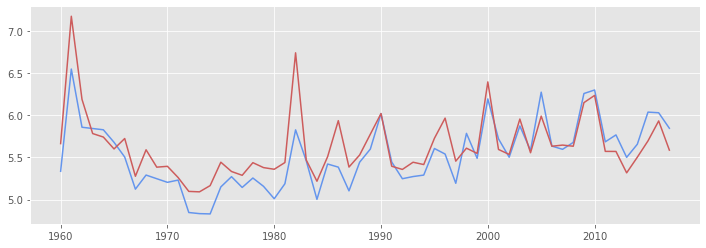


St Emilion:
               skew  kurtosis
Log price  0.432361 -0.108372

Medoc :
               skew  kurtosis
Log price  1.774388  4.532202


,Tn: budburst - flowering,Tn: flowering,Tn: flowering - véraison,Tn: véraison - harvest,Tn: harvest,Tm: budburst - flowering,Tm: flowering,Tm: flowering - véraison,Tm: véraison - harvest,Tm: harvest,...,P: flowering - véraison,P: véraison - harvest,P: harvest,Frost: budburst - flowering,Growing Season Tm,Winter Rain,Floraison date,GDD10,Stress,Log price
1960,9.054412,14.485714,15.455385,14.993333,13.190909,12.882353,18.628571,19.030769,18.444444,15.513636,...,118.8,140.9,209.9,0.000000,16.948634,0.000000,145,1989.8,-77.35,5.664447
1961,8.794118,10.453333,15.214706,15.502273,14.767857,12.645588,14.573333,18.823529,19.543182,18.392857,...,90.0,14.3,92.6,0.000000,17.506011,5.003289,136,2249.1,94.40,7.175271
1962,9.800000,14.020000,15.606557,14.308511,11.209091,13.421429,18.350000,19.372131,18.642553,14.913636,...,37.2,50.4,44.3,0.000000,16.615847,3.417763,159,2111.4,106.75,6.189290
1963,10.750746,14.475000,15.715789,14.208333,11.385714,13.837313,17.250000,19.056140,16.883333,14.575000,...,158.6,139.7,32.1,0.000000,16.104372,2.480921,164,1961.5,-146.10,5.783715
1964,10.868421,15.400000,15.845902,16.165000,12.323333,14.382456,18.335714,19.865574,19.725000,15.126667,...,32.5,60.2,215.0,0.000000,17.648087,1.697386,153,2232.2,100.05,5.742316
1965,10.044737,15.411111,15.185106,13.419149,13.294737,13.022368,18.800000,18.968085,16.259574,16.163158,...,68.4,235.8,18.3,0.000000,15.809836,2.731579,164,1852.7,-167.10,5.601328
1966,9.734286,14.633333,15.089831,14.842222,14.036364,12.991429,18.050000,17.881356,18.931111,17.522727,...,137.8,33.4,87.6,0.000000,16.825137,4.407895,150,2024.2,3.75,5.724985
1967,8.494366,12.794118,16.479167,14.028302,14.494444,11.938028,16.611765,19.835417,17.671698,17.394444,...,37.0,110.5,50.8,0.000000,16.377049,4.029605,153,1987.7,18.45,5.277021
1968,8.926087,12.016667,15.575439,15.056818,13.011538,12.557971,16.316667,19.394737,18.302273,16.065385,...,145.2,203.7,44.1,0.000000,16.419126,2.823529,156,2055.1,-177.35,5.591120
1969,10.546269,14.388235,16.786792,14.228205,12.335000,13.622388,16.547059,20.739623,17.328205,16.455000,...,55.5,171.3,12.7,0.000000,16.714208,2.386842,160,2013.8,-75.55,5.385150


In [95]:
from sklearn.preprocessing import PowerTransformer
from scipy.stats import skew
from sklearn.linear_model import LinearRegression

#prices['Anomaly'] = np.nan
#for year in range(1961, 2018):
#    linreg = LinearRegression()
#    linreg.fit(np.array(range(year-10, year)).reshape(-1,1), prices.loc[year-10 : year-1, 'Price'])
#    prices.loc[year, 'Anomaly'] = prices.loc[year, 'Price'] - linreg.predict(np.array(year).reshape(-1,1))
#

price_st_em = np.log(prices_st_em['Average price']).loc[1960:]
price_medoc = np.log(prices_medoc['Average price']).loc[1960:]
plt.plot(price_st_em, color='cornflowerblue')
plt.plot(price_medoc, color='indianred')
plt.show()

###### HERE THE REPLACEMENT
#wa_long_term = (pd.read_excel('data/wa_long_term.xlsx', index_col = 0).interpolate() - 90) /20
#display(wa_long_term.head())
#sns.lineplot(data = wa_long_term)
#plt.show()
######### Yeo Johnson transofrmation

#price = np.log(price)

#pt = PowerTransformer()
#price = pt.fit_transform(np.log(prices['Price'].loc[1961:]).values.reshape(-1,1))/2

#print(df.agg(['skew', 'kurtosis']).T)


df_st_em['Log price'] = price_st_em
df_medoc['Log price'] = price_medoc

print('\nSt Emilion:')
print(df_st_em[['Log price']].agg(['skew', 'kurtosis']).T)


print('\nMedoc :')
print(df_medoc[['Log price']].agg(['skew', 'kurtosis']).T)

df_st_em.to_excel('data/generated_features_st_em.xlsx')
df_medoc.to_excel('data/generated_features_medoc.xlsx')
display(df_medoc)

Saint-Emilion:


Log price                     1.00
DTR: véraison - harvest       0.61
Stress                        0.58
P: flowering                  0.58
Tn: budburst - flowering      0.55
Stress: flowering             0.53
Stress: véraison - harvest    0.53
GDD10                         0.52
Wind: flowering               0.52
Tm: budburst - flowering      0.48
Name: Log price, dtype: float64


Medoc:


Log price                     1.00
Stress: véraison - harvest    0.62
Sun: véraison - harvest       0.59
DTR: véraison - harvest       0.59
Stress                        0.54
P: véraison - harvest         0.54
ETP: véraison - harvest       0.42
P: flowering                  0.41
Wind: harvest                 0.40
Wind: flowering               0.38
Name: Log price, dtype: float64

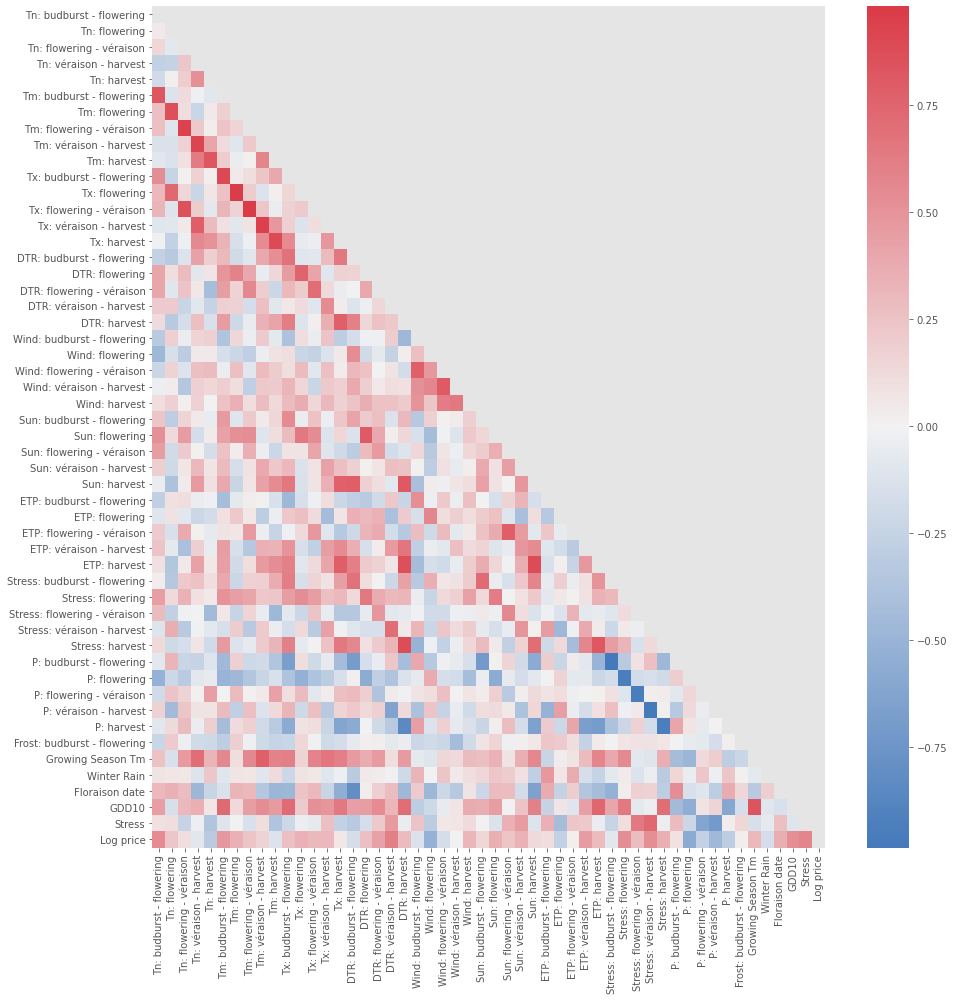

In [96]:
#print(df.loc[1983:1993, :].corr()['Log price'].abs().nlargest(30))
#print(df.loc[1994:2004, :].corr()['Log price'].abs().nlargest(20))
print('Saint-Emilion:')
display(df_st_em.loc[1994:2017, :].reset_index().corr()['Log price'].abs().nlargest(10).round(2))
print('\nMedoc:')
display(df_medoc.loc[1994:2017, :].reset_index().corr()['Log price'].abs().nlargest(10).round(2))

#print('\nCombined:')
#display(pd.concat((df_st_em.loc[1994:2003, :], df_st_em.loc[1994:2003, :]), axis=0).reset_index().corr()['Log price'].abs().nlargest(10))


#print('\Correlated with age:')
#display(pd.concat((df_st_em.loc[1994:2017, :], df_st_em.loc[1994:, :]), axis=0).reset_index().corr()['index'].abs().nlargest(20))

#display(df.loc[2005:, :].corr()['Log price'].abs().nlargest(20))

plt.figure(figsize=(14,14))
mask = np.triu(np.ones_like(pd.concat((df_st_em.loc[1994:, :], df_st_em.loc[1994:, :]), axis=0).corr()))

cmap = sns.diverging_palette(250, 10, as_cmap=True)

#sns.heatmap(pd.concat((df_st_em.loc[1994:2003, :], df_st_em.loc[1994:2003, :]), axis=0).corr(), mask=mask, cmap=cmap)
sns.heatmap(df_st_em.loc[1994:2017, :].corr(), mask=mask, cmap=cmap)

plt.tight_layout()
plt.savefig('views/heatmap.png')
plt.show()

#### GOOD_FEATURES = ['Stress',  'DTR: veraison - vendanges']: Spearman out-sample of 0.76, BEST TO DATE

# Regression

In [100]:
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge, Lasso, LinearRegression

def model_tester(X, y, first, last, width, fixed_1994):
    r2_scores = []
    spearman_scores = []
    X = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
    if width == None:
        predictions = pd.DataFrame(index=range(first + 20, last), columns=['Log Price'])
        coefficients = pd.DataFrame(0, index=range(first, last- 20 +1), columns = ['const']+X.columns.to_list())
        year_range = range(first, last - 20 + 1)

    else:
        predictions = pd.DataFrame(index=range(first + width, last), columns=['Log Price'])
        coefficients = pd.DataFrame(0, index=range(first, last- width +1), columns = ['const']+X.columns.to_list())
        year_range = range(first, last - width + 1)


        
    for year in year_range:
        if width == None: #Want to train with a minimal window of size 20
            oldest_vintage = first
            newest_vintage = year +  20 - 1
            
        else:
            oldest_vintage = year
            newest_vintage = year +  width - 1
        
        y_train = y.loc[oldest_vintage:newest_vintage, 'Log price']
        #X_train = sm.add_constant(X.loc[oldest_vintage-first:newest_vintage-first,:])
        X_train = X.loc[oldest_vintage-first:newest_vintage-first,:]
        
        #mod = sm.OLS(y_train.values.reshape(-1,1), X_train)
        #res = mod.fit()
        #coefs = pd.Series(res.params)
        #mod = Lasso(alpha=0.005)

        mod = LinearRegression()
        mod.fit(X_train, y_train.values)
        coefs = mod.coef_
        coefficients.loc[year, X_train.columns] = coefs
        coefficients.loc[year, 'const'] = mod.intercept_
        
        r2_scores.append(r2_score(mod.predict(X_train),y_train))
        spearman_scores.append(spearmanr(mod.predict(X_train),y_train)[0])
        
        X_test = X.loc[newest_vintage-first+1:newest_vintage-first+1,:]
        #ones = pd.DataFrame(np.ones(1), index=[newest_vintage-first+1], columns=['const'])
        #X_test = pd.concat((ones, X_test), axis=1)
        
        if fixed_1994:
            if year==1994- width -1:
                mod_base = mod
                
            if year >=1994- width -1:
                print(year+ width +1, ': using 1993 model.')
                predictions.loc[newest_vintage+1] = mod_base.predict(X_test.values)[0]

            else:
                predictions.loc[newest_vintage+1] = mod.predict(X_test.values)[0]

        else:
            predictions.loc[newest_vintage+1] = mod.predict(X_test.values)[0]
    return coefficients, r2_scores, spearman_scores, predictions.loc[1994:]

def model_tester_combined(X_medoc, y_medoc, X_st_em, y_st_em, first, last, width, fixed_1994):
    
    X_medoc = pd.DataFrame(StandardScaler().fit_transform(X_medoc), columns=X_medoc.columns)
    X_st_em = pd.DataFrame(StandardScaler().fit_transform(X_st_em), columns=X_st_em.columns)
    
    if width == None:
        predictions_st_em = pd.DataFrame(index=range(first + width, last), columns=['Log Price'])
        predictions_medoc = pd.DataFrame(index=range(first + width, last), columns=['Log Price'])
        year_range = range(first, last - 20 + 1)

    if width != None:
        predictions_st_em = pd.DataFrame(index=range(first + 20, last), columns=['Log Price'])
        predictions_medoc = pd.DataFrame(index=range(first + 20, last), columns=['Log Price'])
        year_range = range(first, last - width + 1)

        
    for year in year_range:
        if width == None: #Want to train with a minimal window of size 20
            oldest_vintage = first
            newest_vintage = year +  20 - 1
            
        else:
            oldest_vintage = year
            newest_vintage = year +  width - 1

        y_medoc_train = y_medoc.loc[oldest_vintage:newest_vintage, 'Log price']
        y_st_em_train = y_st_em.loc[oldest_vintage:newest_vintage, 'Log price']
        y_train = np.concatenate((y_medoc_train, y_st_em_train), axis=0)
        
        X_medoc_train = np.concatenate((X_medoc.loc[oldest_vintage-first:newest_vintage-first,:].values, np.ones((len(X_medoc.loc[oldest_vintage-first:newest_vintage-first,:]), 1))), axis=1)
        X_st_em_train = np.concatenate((X_st_em.loc[oldest_vintage-first:newest_vintage-first,:].values, np.zeros((len(X_medoc.loc[oldest_vintage-first:newest_vintage-first,:]), 1))), axis=1)
        X_train  = np.concatenate((X_medoc_train, X_st_em_train), axis = 0)
        
        mod = LinearRegression()
        mod.fit(X_train, y_train)
        
        X_medoc_test = np.concatenate((X_medoc.loc[newest_vintage-first+1:newest_vintage-first+1,:].values, np.ones((1,1))), axis=1)
        X_st_em_test = np.concatenate((X_st_em.loc[newest_vintage-first+1:newest_vintage-first+1,:].values, np.ones((1,1))), axis=1)

        predictions_medoc.loc[newest_vintage+1] = mod.predict(X_medoc_test)[0]
        predictions_st_em.loc[newest_vintage+1] = mod.predict(X_st_em_test)[0]

    return predictions_medoc, predictions_st_em

In [101]:
def regression(df, first, last, features, width):
    #X['Sq Tn: debourrement - floraison'] = X['Tn: debourrement - floraison']**2
    df = df.loc[first:last]
    #df = df.reset_index()
    X = df.drop('Log price', axis=1)[features]#.reset_index(drop=True)
    y = df[['Log price']]

    
    coefficients, r2_scores, spearman_scores, predictions = model_tester(X, y, first, last, width, fixed_1994 = False)
    
    #sns.lineplot(data=coefficients.iloc[:,1:6]).axhline(0., color='black')
    #ax = plt.gca()
    #ax.set_xticklabels([str(year) + ' - ' + str(year + width - 1) for year in range(1955, 2000, 5)])
    #plt.tight_layout()
    #plt.savefig('views/linreg_coefficients_through_time.png')
    #plt.show()
    
    #plt.figure(figsize=(16,4))
    #sns.lineplot(data=coefficients.iloc[:,0])
    #plt.show()
    
    
    plt.figure(figsize=(16,4))
    plt.plot(predictions, color='red')
    plt.plot(y, color='green')
    plt.show()
    
    return predictions

def score_predictions(predictions, y):
    spearman_r = round(spearmanr(y.loc[1994:2017], predictions.loc[1994:2017])[0], 2)
    mae = round(np.mean(np.abs(predictions.loc[1994:2017].values- y.loc[1994:2017].values)), 2)
    r2 = round(r2_score(y.loc[1994:2017].values, predictions.loc[1994:2017].values), 2)
    return spearman_r, r2, mae

def r_squared(x, y):
    return 1 - np.sum(np.square(x - y))/np.sum(np.square(x - np.mean(x)))

Fixed begin: Medoc


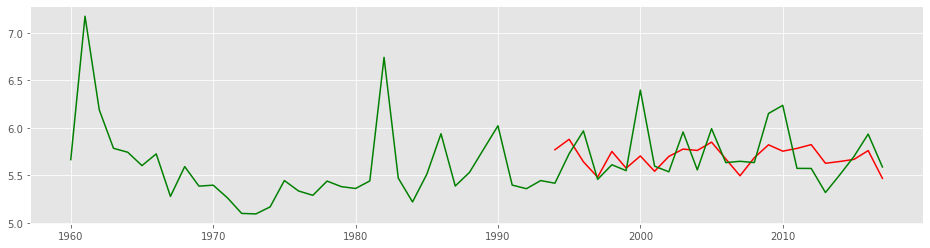

Fixed begin: St-Em


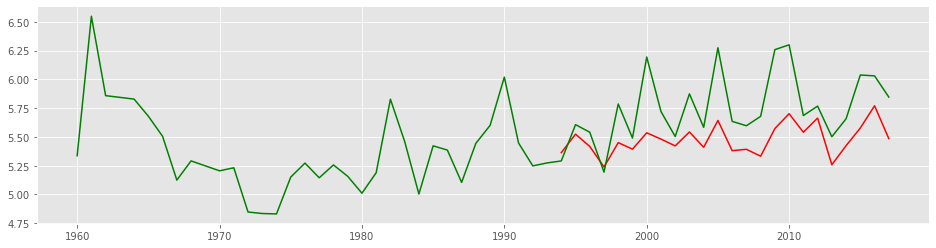

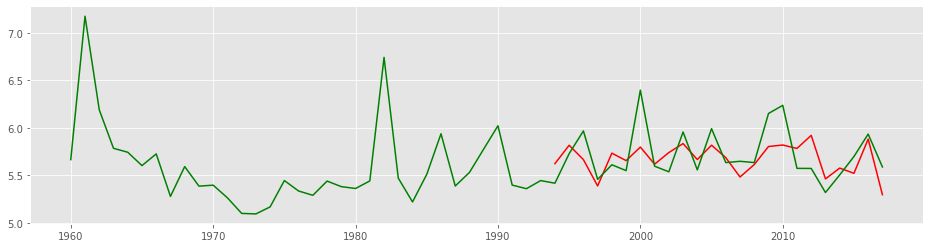

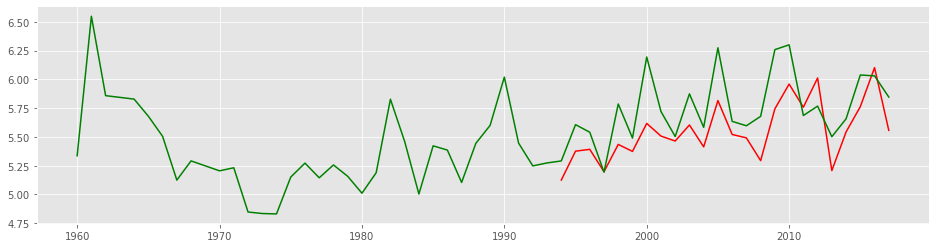

oijoijoij


,"Simple, fixed begin","Simple, sliding windows","Combined, sliding windows"
Médoc: SpearmanR,0.34,0.53,0.55
Saint-Émilion: SpearmanR,0.84,0.84,0.74
Médoc: R2,0.12,0.26,0.32
Saint-Émilion: R2,-0.35,0.13,0.37
Médoc: MAE,0.23,0.25,0.25
Saint-Émilion: MAE,0.33,0.35,0.29


In [102]:
results_df = pd.DataFrame(index = [
    'Médoc: SpearmanR',
    'Saint-Émilion: SpearmanR',
    'Médoc: R2',
    'Saint-Émilion: R2',
    'Médoc: MAE',
    'Saint-Émilion: MAE'
])
### R1 : simple regression, without Year, on 20 years. False combined prediction. ###
results_df['Simple, fixed begin'] = 0
print('Fixed begin: Medoc')
predictions_medoc = regression(df_medoc, 1960, 2017, ['Stress', 'P: flowering', 'DTR: véraison - harvest'], None)
print('Fixed begin: St-Em')
predictions_st_em = regression(df_st_em, 1960, 2017, ['Stress', 'P: flowering', 'DTR: véraison - harvest'], None)

results_df.iloc[0::2, 0] = score_predictions(predictions_medoc, df_medoc['Log price'])
results_df.iloc[1::2, 0] = score_predictions(predictions_st_em, df_st_em['Log price'])

### R2 : simple regression, with Year, on 20 years. False combined prediction. ###
results_df['Simple, sliding windows'] = 0
df_medoc_copy = df_medoc.copy()
df_st_em_copy = df_st_em.copy()
df_medoc_copy['Vintage'] = df_medoc_copy.index
df_st_em_copy['Vintage'] = df_st_em_copy.index

predictions_medoc = regression(df_medoc_copy, 1960, 2017, ['Stress', 'P: flowering', 'DTR: véraison - harvest'], 20)
predictions_st_em = regression(df_st_em_copy, 1960, 2017, ['Stress', 'P: flowering', 'DTR: véraison - harvest'], 20)
predictions_global = 0.5*(predictions_medoc + predictions_st_em)

results_df.iloc[0::2, 1] = score_predictions(predictions_medoc, df_medoc['Log price'])
results_df.iloc[1::2, 1] = score_predictions(predictions_st_em, df_st_em['Log price'])

### R3 : simple regression, without Year, on 20 years. True combined training. ###
results_df['Combined, sliding windows'] = 0
first = 1960
last = 2017
width = 20
df_medoc = df_medoc.loc[first:last]
X_medoc = df_medoc.drop('Log price', axis=1)[['Stress', 'P: flowering', 'DTR: véraison - harvest']]#.reset_index(drop=True)
y_medoc = df_medoc[['Log price']]

df_st_em = df_st_em.loc[first:last]
X_st_em = df_st_em.drop('Log price', axis=1)[['Stress', 'P: flowering', 'DTR: véraison - harvest']]#.reset_index(drop=True)
y_st_em = df_st_em[['Log price']]
print('oijoijoij')
predictions_medoc, predictions_st_em = model_tester_combined(X_medoc, y_medoc, X_st_em, y_st_em, first, last, width, fixed_1994 = False)
predictions_global = 0.5*(predictions_medoc + predictions_st_em)
results_df.iloc[0::2, 2] = score_predictions(predictions_medoc, df_medoc['Log price'])
results_df.iloc[1::2, 2] = score_predictions(predictions_st_em, df_st_em['Log price'])
display(results_df)
results_df.to_excel('tables/regression_results.xlsx')

# Appendix: PCA

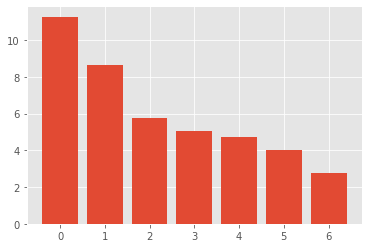

,0,1,2,3,4,5,6
1980,-4.354726,1.794528,0.970380,0.180457,1.694633,-0.256372,-1.641731
1981,0.832289,-2.561261,-1.263189,1.072136,0.367313,-0.680976,-1.267017
1982,2.985240,-0.121465,-2.080035,-0.772342,-1.123292,3.158297,2.591032
1983,1.130416,2.353051,2.173226,-0.231008,-3.864273,-0.755364,-1.200368
1984,-1.813309,-1.169158,-1.870055,-2.802077,1.346254,-1.121126,-0.302894


In [82]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Create scaler: scaler
scaler = StandardScaler()

# Create a PCA instance: pca
pca = PCA(n_components=7)

# Create pipeline: pipeline
pipeline = make_pipeline(scaler,pca)

X = df.drop('Log price', axis=1).loc[1961:1994]

X = pd.DataFrame(StandardScaler().fit_transform(X), index=X.index, columns=X.columns).loc[1980:,:]


pipeline.fit(X.dropna(axis=0))
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_)
plt.show()

X = X.dropna(axis=0)
X2 = pd.DataFrame(pca.transform(X), index=X.index)
display(X2.head())

In [83]:
from mpl_toolkits.mplot3d import Axes3D
%matplotlib qt


def myplot(score,coeff,labels=None):
    xs = score[:,0]
    ys = score[:,2]
    n = coeff.shape[0]
    #plt.scatter(xs ,ys) #without scaling
    for i in range(len(labels)):
        plt.arrow(0, 0, coeff[0,i], coeff[1,i],color = 'r',alpha = 0.5)
        if labels is None:
            plt.text(coeff[0,i]* 1.10, coeff[1,i] * 1.10, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            plt.text(coeff[0,i]* 1.10, coeff[1,i] * 1.10, labels[i], color = 'g', ha = 'center', va = 'center')

            
fig = plt.figure(figsize=(13,13))
ax = fig.add_subplot(111, projection='3d')

coef = pca.components_

ax.scatter(coef[0,:] , coef[1, :] , coef[2, :])

for i in range(len(X.columns)):
    ax.text(coef[0,i]+np.mean(coef[0,:])/1000,coef[1,i]+np.mean(coef[1,:])/1000 ,coef[2,i]+np.mean(coef[2,:])/1000, list(X.columns)[i], zdir=None)

# 